# Linear SVM Classifiaction

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [2]:
iris = datasets.load_iris()
X = iris["data"][:,(2,3)] # petal length,petal width
y = (iris["target"] == 2).astype(np.float64) # Iris Verginica

In [3]:
X[:5]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

In [4]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [5]:
svm_clf = Pipeline([
    ("scaler",StandardScaler()), # Scaling
    ("svm_clf",LinearSVC(C=1,loss="hinge")) # Loss function -> hinge
])

svm_clf.fit(X,y)
y_predict = svm_clf.predict(X)
y_predict

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [6]:
print(y == y_predict) # Comparing

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True  True  True
  True False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]


In [7]:
score = (y == y_predict).astype(np.float64)
print(f"Accurary for training set: {round(score.sum()/len(score) * 100, 2)}%")

Accurary for training set: 96.0%


In [8]:
svm_clf.predict([[5.5,1.7]]) # True 

array([1.])

# Nonlinear SVM Classification

Generating Data with non_linear decision boundary

In [29]:
from sklearn.datasets import make_moons

In [30]:
X,y = make_moons(n_samples=100,noise = 0.15)

In [31]:
X[:5]

array([[ 0.45790732, -0.60476277],
       [ 2.03609895,  0.45152454],
       [-0.46786916,  0.82091726],
       [ 0.05359718,  0.11239301],
       [ 0.22924792, -0.23343677]])

In [32]:
y[:5]

array([1, 1, 0, 1, 1])

In [33]:
import matplotlib.pyplot as plt

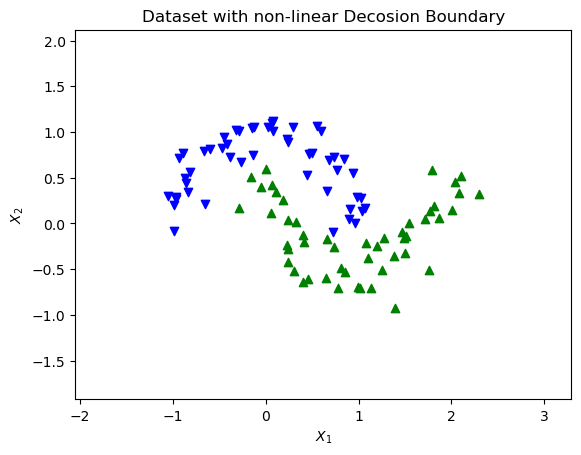

In [34]:
plt.scatter(X[(y==0),0],X[(y==0),1],c="b",marker="v")
plt.scatter(X[(y==1),0],X[(y==1),1],c="g",marker="^")
plt.axis([X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Dataset with non-linear Decosion Boundary")
plt.show()

Training Model

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC

In [36]:
polynomial_svm_clf = Pipeline([
    ("poly_features",PolynomialFeatures(degree=3)),
    ("scaler",StandardScaler()),
    ("svm_clf",LinearSVC(C=10,loss="hinge"))
])
polynomial_svm_clf.fit(X,y)

C:\Users\bhatm\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge'))])

In [38]:
y_predict = polynomial_svm_clf.predict(X)
score = (y_predict==y).astype(np.float64)
print(f"Accuracy: {round(sum(score)/len(score) *100, 2)}%")

Accuracy: 99.0%


In [39]:
polynomial_svm_clf.named_steps["svm_clf"].coef_

array([[ 0.        , -2.00749906, -0.67922876, -4.08409324, -0.74969276,
        -0.07429492,  7.48583004, -1.38966858,  2.27824051, -1.58799332]])

In [45]:
def plot_predictions(clf, axes):
    # Create a grid of points
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    
    # Flatten grid and predict
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    
    # Use contourf to fill the decision regions
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)




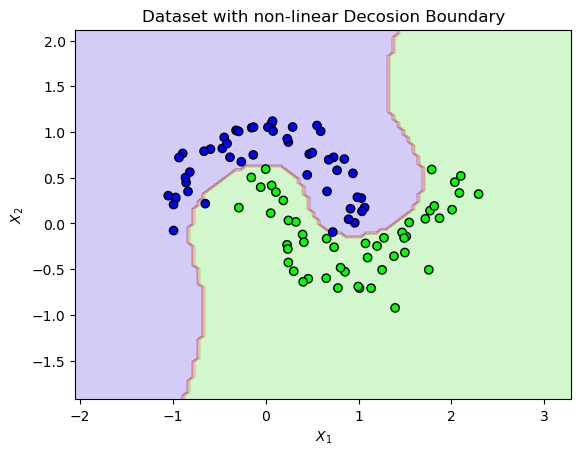

In [46]:
# Plotting(Method 1)
plot_predictions(polynomial_svm_clf, [X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Dataset with non-linear Decosion Boundary")
plt.show()

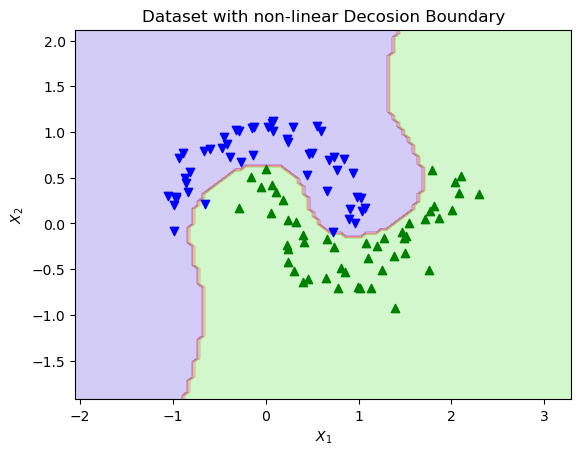

In [47]:
# Plotting (Method 2)
plot_predictions(polynomial_svm_clf, [X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[(y==0),0],X[(y==0),1],c="b",marker="v")
plt.scatter(X[(y==1),0],X[(y==1),1],c="g",marker="^")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Dataset with non-linear Decosion Boundary")
plt.show()

## Polynomial Kernal

In [48]:
from sklearn.svm import SVC

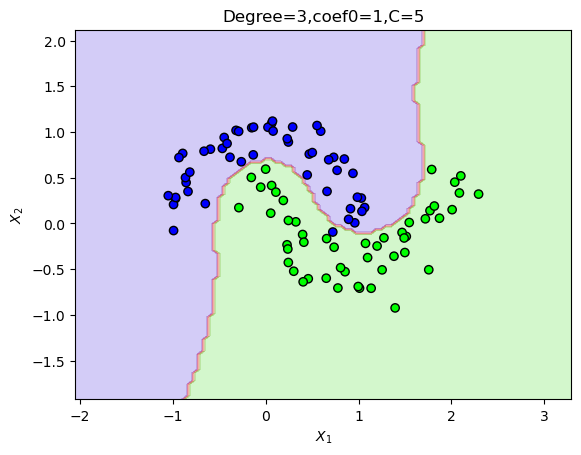

In [55]:
poly_kernal_svm_clf_d3 = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="poly",degree=3,coef0=1,C=5))
])
poly_kernal_svm_clf_d3.fit(X,y)
plot_predictions(poly_kernal_svm_clf_d3,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Degree=3,coef0=1,C=5")
plt.show()

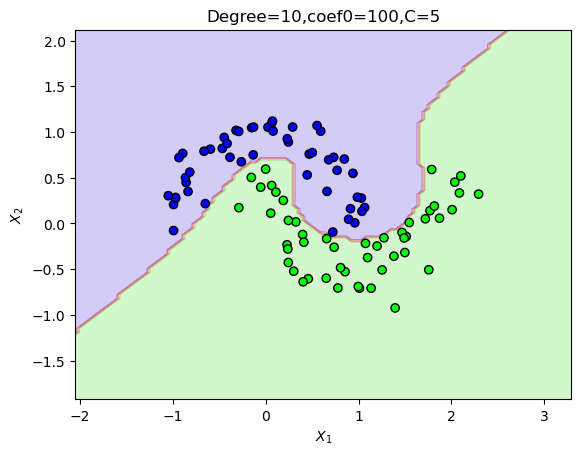

In [57]:
poly_kernal_svm_clf_d10 = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="poly",degree=10,coef0=100,C=5))
])
poly_kernal_svm_clf_d10.fit(X,y)
plot_predictions(poly_kernal_svm_clf_d10,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Degree=10,coef0=100,C=5")
plt.show()

## Gaussian RBF Kernel (Radial Basis Function)

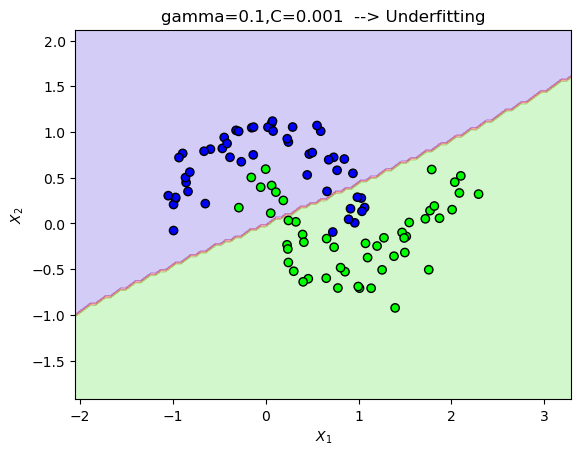

In [65]:
rbf_kernel_svm_clf = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="rbf",gamma=0.1,C=0.001))
])
rbf_kernel_svm_clf.fit(X,y)
plot_predictions(rbf_kernel_svm_clf,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("gamma=0.1,C=0.001  --> Underfitting")
plt.show()

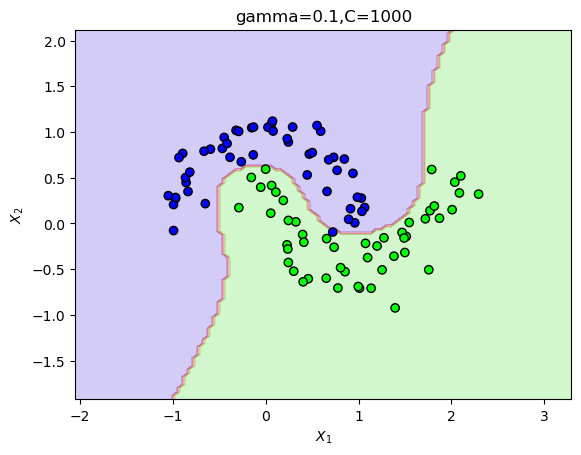

In [62]:
rbf_kernel_svm_clf = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="rbf",gamma=0.1,C=1000))
])
rbf_kernel_svm_clf.fit(X,y)
plot_predictions(rbf_kernel_svm_clf,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("gamma=0.1,C=1000")
plt.show()

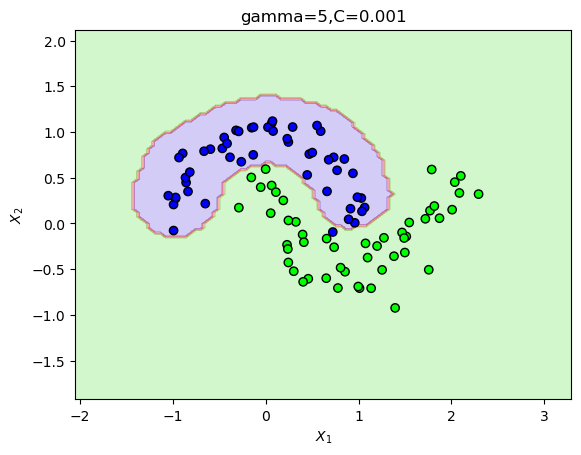

In [60]:
rbf_kernel_svm_clf = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="rbf",gamma=5,C=0.001))
])
rbf_kernel_svm_clf.fit(X,y)
plot_predictions(rbf_kernel_svm_clf,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("gamma=5,C=0.001")
plt.show()

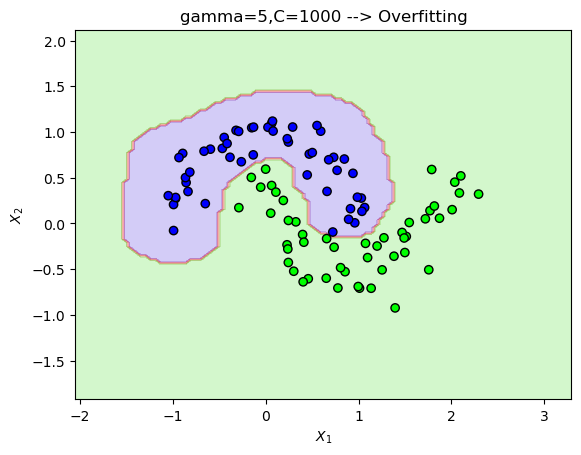

In [66]:
rbf_kernel_svm_clf = Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="rbf",gamma=5,C=1000))
])
rbf_kernel_svm_clf.fit(X,y)
plot_predictions(rbf_kernel_svm_clf,[X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg, edgecolors='k')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("gamma=5,C=1000 --> Overfitting")
plt.show()